In [2]:
!pip install tensorflow

   ---------------------------------------- 0.0/350.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/350.8 MB 1.3 MB/s eta 0:04:35
   ---------------------------------------- 0.1/350.8 MB 991.0 kB/s eta 0:05:54
   ---------------------------------------- 0.1/350.8 MB 845.5 kB/s eta 0:06:55
   ---------------------------------------- 0.1/350.8 MB 901.1 kB/s eta 0:06:30
   ---------------------------------------- 0.1/350.8 MB 901.1 kB/s eta 0:06:30
   ---------------------------------------- 0.1/350.8 MB 901.1 kB/s eta 0:06:30
   ---------------------------------------- 0.1/350.8 MB 901.1 kB/s eta 0:06:30
   ---------------------------------------- 0.1/350.8 MB 901.1 kB/s eta 0:06:30
   ---------------------------------------- 0.1/350.8 MB 901.1 kB/s eta 0:06:30
   ---------------------------------------- 0.1/350.8 MB 901.1 kB/s eta 0:06:30
   ---------------------------------------- 0.1/350.8 MB 901.1 kB/s eta 0:06:30
   ---------------------------------------- 0.2/350

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
googleapis-common-protos 1.63.0 requires protobuf!=3.20.0,!=3.20.1,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0.dev0,>=3.19.5, but you have protobuf 7.35.1 which is incompatible.
google-api-core 2.19.0 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0.dev0,>=3.19.5, but you have protobuf 7.35.1 which is incompatible.
google-cloud-aiplatform 1.53.0 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.19.5, but you have protobuf 7.35.1 which is incompatible.
google-cloud-resource-manager 1.12.3 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.19.5, but you have protobuf 7.35.1 which is incompatible.
grpc-google-iam-v1 0.13.0 requires protobuf!=3.20.0,!=3.20.1,!=

In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

HOURS_PER_WEEK = 168
TEST_WEEKS = 104
SEED = 42
SEASONALITY = 52

In [14]:
# ----------------------------------------------------------------------
# Reuse the Part 3 helpers so diagnostics/metrics are identical
# ----------------------------------------------------------------------

def evaluate(name, y_true, y_pred, y_train, seasonality=SEASONALITY):
    y_pred = y_pred.reindex(y_true.index)
    err = y_pred.to_numpy() - y_true.to_numpy()
    yt = y_train.to_numpy()
    scale = np.mean(np.abs(yt[seasonality:] - yt[:-seasonality]))
    return {
        "model": name,
        "MAE": float(np.mean(np.abs(err))),
        "RMSE": float(np.sqrt(np.mean(err ** 2))),
        "MASE": float(np.mean(np.abs(err)) / scale),
        "Bias": float(np.mean(err)),
    }

In [15]:
def _set_seeds(seed=SEED):
    np.random.seed(seed)
    tf.random.set_seed(seed)


# ----------------------------------------------------------------------
# 1. Feature engineering (hourly calendar features)
# ----------------------------------------------------------------------

def make_hourly_features(load: pd.Series) -> pd.DataFrame:
    """
    Target 'load' plus cyclic calendar features so the network knows where in
    the daily / weekly / annual cycle each hour sits.
    """
    idx = load.index
    hour = idx.hour.to_numpy()
    dow = idx.dayofweek.to_numpy()
    doy = idx.dayofyear.to_numpy()

    df = pd.DataFrame({"load": load.to_numpy()}, index=idx)
    df["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    df["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    df["dow_sin"] = np.sin(2 * np.pi * dow / 7)
    df["dow_cos"] = np.cos(2 * np.pi * dow / 7)
    df["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    df["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
    return df

In [16]:
# ----------------------------------------------------------------------
# 2. Scaling (fit on train only) + windowing
# ----------------------------------------------------------------------

def scale_train_only(features: pd.DataFrame, n_train_hours: int):
    """Fit a MinMax scaler on the training rows only, transform everything."""
    scaler = MinMaxScaler()
    scaler.fit(features.iloc[:n_train_hours])
    scaled = pd.DataFrame(scaler.transform(features),
                          index=features.index, columns=features.columns)
    return scaled, scaler


def make_windows(scaled: np.ndarray, lookback: int, horizon: int,
                 stride: int, target_col: int = 0):
    """
    Sliding windows. X[i] = lookback hours of all features,
    y[i] = next `horizon` values of the (scaled) target column.
    """
    X, y = [], []
    n = len(scaled)
    for start in range(0, n - lookback - horizon + 1, stride):
        X.append(scaled[start:start + lookback])
        y.append(scaled[start + lookback:start + lookback + horizon, target_col])
    return np.asarray(X), np.asarray(y)

In [17]:
# ----------------------------------------------------------------------
# 3. Model + light hyperparameter tuning
# ----------------------------------------------------------------------

def build_lstm(n_features, horizon, units=64, n_layers=1, dropout=0.1, lr=1e-3):
    _set_seeds()
    model = Sequential([Input(shape=(None, n_features))])
    for i in range(n_layers):
        model.add(LSTM(units, return_sequences=(i < n_layers - 1)))
        if dropout:
            model.add(Dropout(dropout))
    model.add(Dense(horizon))
    model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss="mse")
    return model


def tune_lstm(X_tr, y_tr, X_val, y_val, n_features, horizon,
              grid=None, epochs=30, batch_size=64, verbose=0):
    """
    Small manual grid search over architecture/regularisation, selected by
    validation RMSE. Keep the grid modest -- LSTMs are slow to train.
    """
    if grid is None:
        grid = [
            {"units": 32, "n_layers": 1, "dropout": 0.0},
            {"units": 64, "n_layers": 1, "dropout": 0.1},
            {"units": 64, "n_layers": 2, "dropout": 0.2},
        ]
    es = EarlyStopping(patience=5, restore_best_weights=True)
    results = []
    best = None
    for cfg in grid:
        model = build_lstm(n_features, horizon, lr=1e-3, **cfg)
        model.fit(X_tr, y_tr, validation_data=(X_val, y_val),
                  epochs=epochs, batch_size=batch_size, verbose=verbose,
                  callbacks=[es])
        val_rmse = float(np.sqrt(model.evaluate(X_val, y_val, verbose=0)))
        results.append({**cfg, "val_rmse": val_rmse})
        if best is None or val_rmse < best["val_rmse"]:
            best = {"cfg": cfg, "model": model, "val_rmse": val_rmse}
    return best, pd.DataFrame(results).sort_values("val_rmse")

In [18]:
# ----------------------------------------------------------------------
# 4. Rolling week-ahead forecast across the test window
# ----------------------------------------------------------------------

def rolling_weekly_forecast(model, scaled: pd.DataFrame, scaler,
                            n_test_weeks: int, lookback: int,
                            target_col: int = 0):
    """
    For each of the last `n_test_weeks` weeks, feed the preceding `lookback`
    hours and predict the next 168 hours. Inverse-transform, then aggregate
    each block to a weekly mean. Returns hourly and weekly forecast frames.
    """
    values = scaled.to_numpy()
    n = len(values)
    test_start = n - n_test_weeks * HOURS_PER_WEEK

    # inverse-transform helper for the target column only
    lo, hi = scaler.data_min_[target_col], scaler.data_max_[target_col]
    def inv(x):
        return x * (hi - lo) + lo

    hourly_pred, hourly_true, hourly_idx = [], [], []
    for b in range(n_test_weeks):
        origin = test_start + b * HOURS_PER_WEEK
        window = values[origin - lookback:origin][np.newaxis, ...]
        pred_scaled = model.predict(window, verbose=0)[0]
        pred = inv(pred_scaled)
        true = inv(values[origin:origin + HOURS_PER_WEEK, target_col])
        hourly_pred.append(pred)
        hourly_true.append(true)
        hourly_idx.append(scaled.index[origin:origin + HOURS_PER_WEEK])

    hourly_pred = np.concatenate(hourly_pred)
    hourly_true = np.concatenate(hourly_true)
    hourly_index = pd.DatetimeIndex(np.concatenate([i.to_numpy() for i in hourly_idx]))

    hourly = pd.DataFrame({"actual": hourly_true, "pred": hourly_pred},
                          index=hourly_index)
    weekly = hourly.resample("W").mean()
    return hourly, weekly

In [19]:
# ----------------------------------------------------------------------
# 5. Metrics
# ----------------------------------------------------------------------

def hourly_metrics(hourly: pd.DataFrame) -> dict:
    err = hourly["pred"].to_numpy() - hourly["actual"].to_numpy()
    mape = np.mean(np.abs(err / hourly["actual"].to_numpy())) * 100
    return {
        "MAE": float(np.mean(np.abs(err))),
        "RMSE": float(np.sqrt(np.mean(err ** 2))),
        "MAPE_%": float(mape),
        "Bias": float(np.mean(err)),
    }

In [20]:
# ----------------------------------------------------------------------
# Orchestration
# ----------------------------------------------------------------------

def run_part6(hourly_load: pd.Series, test_weeks: int = TEST_WEEKS,
              lookback: int = HOURS_PER_WEEK, horizon: int = HOURS_PER_WEEK,
              stride: int = 24, epochs: int = 30, batch_size: int = 64,
              comparison_rmse: dict | None = None, save_dir: str | None = None,
              tune: bool = True):
    _set_seeds()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)

    feats = make_hourly_features(hourly_load)
    n_hours = len(feats)
    n_test_hours = test_weeks * HOURS_PER_WEEK
    n_train_hours = n_hours - n_test_hours

    scaled, scaler = scale_train_only(feats, n_train_hours)

    # build training windows from the TRAIN portion only
    train_scaled = scaled.iloc[:n_train_hours].to_numpy()
    X, y = make_windows(train_scaled, lookback, horizon, stride)

    # validation = last 15% of training windows (chronological)
    n_val = max(1, int(0.15 * len(X)))
    X_tr, y_tr = X[:-n_val], y[:-n_val]
    X_val, y_val = X[-n_val:], y[-n_val:]
    n_features = X.shape[2]
    print(f"Train windows: {X_tr.shape}, Val: {X_val.shape}, features={n_features}")

    if tune:
        best, tune_table = tune_lstm(X_tr, y_tr, X_val, y_val, n_features, horizon,
                                     epochs=epochs, batch_size=batch_size)
        print("\nHyperparameter tuning (val RMSE):")
        print(tune_table.round(4).to_string(index=False))
        model = best["model"]
        print(f"\nBest config: {best['cfg']}  (val RMSE {best['val_rmse']:.4f})")
    else:
        model = build_lstm(n_features, horizon)
        EarlyStopping(patience=5, restore_best_weights=True)
        model.fit(X_tr, y_tr, validation_data=(X_val, y_val),
                  epochs=epochs, batch_size=batch_size, verbose=0)

    hourly, weekly = rolling_weekly_forecast(model, scaled, scaler,
                                             test_weeks, lookback)

    hm = hourly_metrics(hourly)
    print("\nHourly forecast metrics (rolling week-ahead over 2 years):")
    print(pd.DataFrame([hm]).round(3).to_string(index=False))

    # weekly comparison, aligned with Parts 2-5
    weekly = weekly.dropna()
    weekly_full = hourly_load.resample("W").mean() / 1.0
    y_train_weekly = weekly_full.iloc[:-test_weeks]
    wk_metrics = evaluate("LSTM (weekly agg)", weekly["actual"], weekly["pred"],
                          y_train_weekly)
    print("\nWeekly-aggregated metrics (comparable to Parts 2-5):")
    print(pd.DataFrame([wk_metrics]).round(3).to_string(index=False))

    if comparison_rmse:
        comp = [{"model": "LSTM (weekly agg)", "RMSE": wk_metrics["RMSE"]}]
        comp += [{"model": k, "RMSE": v} for k, v in comparison_rmse.items()]
        print("\nRMSE comparison (weekly):")
        print(pd.DataFrame(comp).sort_values("RMSE").round(3).to_string(index=False))

    if save_dir:
        hourly.to_csv(os.path.join(save_dir, "lstm_hourly_forecast.csv"))
        weekly.to_csv(os.path.join(save_dir, "lstm_weekly_forecast.csv"))
        fig, ax = plt.subplots(figsize=(13, 5))
        ax.plot(weekly.index, weekly["actual"], color="black", lw=2, label="actual")
        ax.plot(weekly.index, weekly["pred"], color="tab:purple", lw=1.6, label="LSTM (weekly agg)")
        ax.set_title("LSTM week-ahead forecast, aggregated to weekly")
        ax.set_ylabel("Load (GW)"); ax.legend()
        fig.tight_layout()
        fig.savefig(os.path.join(save_dir, "lstm_weekly_forecast.png"), dpi=150, bbox_inches="tight")

    return model, hm, wk_metrics, (hourly, weekly)

Train windows: (1156, 168, 7), Val: (203, 168, 7), features=7

Hyperparameter tuning (val RMSE):
 units  n_layers  dropout  val_rmse
    64         2      0.2    0.0721
    64         1      0.1    0.0794
    32         1      0.0    0.0919

Best config: {'units': 64, 'n_layers': 2, 'dropout': 0.2}  (val RMSE 0.0721)

Hourly forecast metrics (rolling week-ahead over 2 years):
 MAE  RMSE  MAPE_%  Bias
2.57 3.724   4.933 0.545

Weekly-aggregated metrics (comparable to Parts 2-5):
            model   MAE  RMSE  MASE  Bias
LSTM (weekly agg) 1.657 2.155 1.238  0.53

RMSE comparison (weekly):
              model  RMSE
  LSTM (weekly agg) 2.155
    feature RF (P5) 2.970
seasonal naive (P2) 3.007
  SARIMAX+temp (P4) 3.553


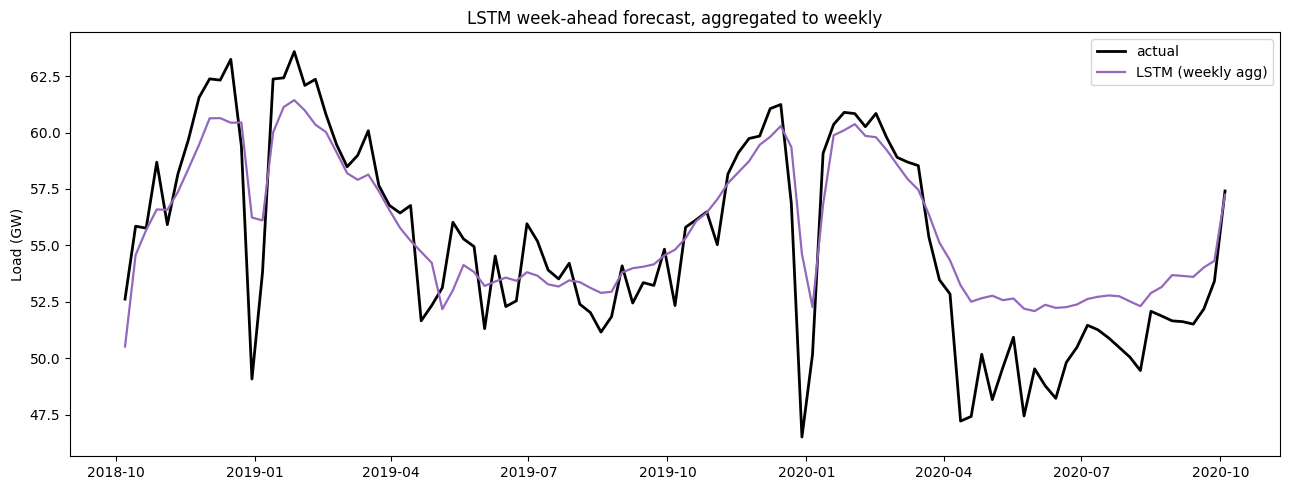

In [24]:
hourly_load = pd.read_csv("data/processed/hourly_load.csv", index_col=0, parse_dates=True).squeeze("columns")
hourly_load = hourly_load / 1000.0     # MW -> GW, to match Parts 2-5

model, hourly_m, weekly_m, (hourly, weekly) = run_part6(
    hourly_load, test_weeks=104, epochs=30,
    comparison_rmse={"seasonal naive (P2)": 3.007, "feature RF (P5)": 2.970,
                     "SARIMAX+temp (P4)": 3.553},
    save_dir="outputs/06",
)